# Assignment 02 — Application 3: E-Commerce Customer Behaviour & Interest

**Student:** _<your name>_ &nbsp;&nbsp; **ID:** _<your id>_ &nbsp;&nbsp; **Class:** _<class>_
&nbsp;&nbsp; **Date:** 2026-09-03

### What this application does, in one sentence

Given the details of a completed online order — how fast it was delivered, what was
bought, how it was paid for, and the review comment the customer wrote — we predict
whether that customer left a **good review (4–5 stars)** or a **bad one (1–3 stars)**.

### Why it is useful

If a company can guess *before* the review is posted that a customer is unhappy, it can
act: send a support message, speed up a shipment, or hold back a "please rate us"
e-mail. This notebook builds that predictor end to end and saves it so the web and
mobile apps can use it without re-training anything.

### The plan for the whole notebook

```
Get the data → Understand it → Clean it → Turn it into numbers → Train models
→ Check how good they are → Save the best one → Hand it to the apps
```

One thing that makes this application different from the diabetes and house-price ones:
**one "example" is not one CSV row.** The raw data is spread across several files
(orders, items bought, payments, products, reviews). We first stitch them together so
that **one row = one order**. And each order is described in **two ways at once**: a set
of plain numbers (price, delivery days, …) *and* the free-text review comment.

Every code cell below is followed by a short written explanation of what came out and
what it means.

## 0. Setup

We fix a single random number (`RANDOM_SEED = 42`) so that every step that involves
chance — shuffling, sampling, splitting — comes out the same every time the notebook is
run. We also print the exact library versions, so the experiment can be reproduced on
another machine.

In [1]:
import sys, platform, random, time, warnings, re, json, os
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib, matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Python      :", sys.version.split()[0], "on", platform.system(), platform.release())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy       :", scipy.__version__)
print("matplotlib  :", matplotlib.__version__)
print("joblib      :", joblib.__version__)
print("RANDOM_SEED  =", RANDOM_SEED)

Python      : 3.13.14 on Windows 11
numpy       : 2.5.2
pandas      : 3.0.5
scikit-learn: 1.9.0
scipy       : 1.18.1
matplotlib  : 3.11.1
joblib      : 1.5.3
RANDOM_SEED  = 42


## 1. Problem definition

**Goal of this section:** state precisely *what* we predict, *from what*, and *why we
framed it this way* — before touching any code.

### 1.1 The real situation

An online marketplace finishes tens of thousands of orders a day. A few days after each
delivery it e-mails the customer a short survey: a **1-to-5 star rating** and an
optional **comment box**. A 1-star review that becomes public, or a customer who never
comes back, is expensive. So the company would like an early warning: *"this particular
order is likely to end badly."*

We use the **Olist** dataset — about 100,000 real orders placed on Brazilian
marketplaces between 2016 and 2018, each with its final star rating and (sometimes) a
written comment.

### 1.2 How we turn that into a prediction task

We predict a **yes/no answer** (this is called *binary classification* — "binary"
because there are exactly two possible answers). The thing we predict — the "answer
key" — is called the **target**:

```
satisfied = 1  if the customer gave 4 or 5 stars   (a good review)
          = 0  if the customer gave 1, 2 or 3 stars (a bad review)
```

**Why collapse 5 star levels into just 2?** Two reasons. (1) The business decision is
itself yes/no — either you step in to save the order or you don't; the difference
between 1 and 2 stars doesn't change that. (2) The middle score (3 stars) is rare
(~8% of orders) and, in every breakdown we look at later, 3-star customers behave like
the unhappy group, not a separate "neutral" group.

### 1.3 What we predict *from* (the inputs)

Each order is described two ways:

* **Plain numbers about the order** — total price, shipping cost, how many items, how
  it was paid, how many days delivery took, how many days late or early it was versus
  the promised date, the product category, the customer's region, when the order was
  placed.
* **The review comment text** — in Portuguese, present for about 41% of orders.

The assignment asks specifically: *does adding the comment text actually make the
prediction better than the plain numbers alone?* We answer that with a direct
comparison in sections 17–18.

## 2. Dataset source

**Goal:** record exactly where the data comes from and which parts of it we use, so
the work can be reproduced.

**Dataset:** *Brazilian E-Commerce Public Dataset by Olist*, from Kaggle
(<https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce>, licence CC BY-NC-SA
4.0). Downloaded on 2026-09-03 into `customer_behaviour/data/`. It is a genuine export
from Olist's systems; customer names and ids were already replaced with random codes by
the publisher.

**It is not one file — it is nine**, each describing a different "thing", linked by id
columns:

| file | one row is… | what we take from it |
|---|---|---|
| `olist_orders_dataset.csv` | one order | the dates (placed, delivered, promised) and the order status |
| `olist_order_reviews_dataset.csv` | one review | the star score (→ our target) and the comment text |
| `olist_order_items_dataset.csv` | one line item in an order | price, shipping, which seller, which product — we add these up per order |
| `olist_order_payments_dataset.csv` | one payment on an order | payment method, instalments, amount — also added up per order |
| `olist_products_dataset.csv` | one product | its category, weight, number of photos, description length |
| `product_category_name_translation.csv` | one category | the English name of each Portuguese category |
| `olist_customers_dataset.csv` | one customer key | which Brazilian state the customer is in |
| `olist_sellers_dataset.csv`, `olist_geolocation_dataset.csv` | — | not used (seller and map detail are out of scope here) |

Section 3 combines these into **one table with one row per order**.

## 3. Dataset loading

**Approach:** the model needs one row per order, but the raw files store data at
different levels of detail — an order can have several items and several payments. So
the plan is:

1. Load all nine files.
2. **Summarise the many-rows-per-order files down to one row per order** — e.g. add up
   all item prices into a single `price_total`, count the distinct sellers, take the
   main payment method. This is the *"transactions → one customer/order profile →
   feature vector"* step the assignment describes.
3. If an order has more than one review (a few customers answered the survey twice),
   keep only the earliest answered one.
4. Join everything onto the orders table.

We keep only orders that actually received a rating (an *inner join* on the reviews
table) — those are the only ones we can learn from, because only they have an answer
key.

In [2]:
D = "../data/"

def read_csv_smart(path, **kw):
    # The Olist reviews file has circulated as both UTF-8 and Latin-1. Try UTF-8,
    # fall back to Latin-1, last resort replace the few undecodable bytes.
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="utf-8", encoding_errors="replace", **kw)

orders = read_csv_smart(D+"olist_orders_dataset.csv",
        parse_dates=["order_purchase_timestamp","order_approved_at",
                     "order_delivered_carrier_date","order_delivered_customer_date",
                     "order_estimated_delivery_date"])
items    = read_csv_smart(D+"olist_order_items_dataset.csv")
pays     = read_csv_smart(D+"olist_order_payments_dataset.csv")
reviews  = read_csv_smart(D+"olist_order_reviews_dataset.csv",
                       parse_dates=["review_creation_date","review_answer_timestamp"])
products = read_csv_smart(D+"olist_products_dataset.csv")
custs    = read_csv_smart(D+"olist_customers_dataset.csv")
catmap   = read_csv_smart(D+"product_category_name_translation.csv")

print("raw shapes:")
for n,x in [("orders",orders),("order_items",items),("order_payments",pays),
            ("order_reviews",reviews),("products",products),("customers",custs)]:
    print(f"  {n:16s}{x.shape}")

# --- one review per order (earliest answered) ---
rv = (reviews.sort_values("review_answer_timestamp")
             .drop_duplicates("order_id", keep="first")
             [["order_id","review_score","review_comment_message"]])
print("\nreviews: unique orders =", rv.order_id.nunique(),
      "| multi-review orders =", (reviews.groupby('order_id').size()>1).sum())

# --- aggregate line items to the order ---
it = items.groupby("order_id").agg(
        n_items=("order_item_id","count"),
        n_sellers=("seller_id","nunique"),
        price_total=("price","sum"),
        freight_total=("freight_value","sum"),
        main_product_id=("product_id","first")).reset_index()

# --- aggregate payments to the order ---
pm = pays.groupby("order_id").agg(
        payment_value_total=("payment_value","sum"),
        max_installments=("payment_installments","max"),
        n_payment_types=("payment_type","nunique")).reset_index()
main_pt = (pays.sort_values("payment_value", ascending=False)
               .drop_duplicates("order_id", keep="first")
               [["order_id","payment_type"]].rename(columns={"payment_type":"main_payment_type"}))

# --- product + english category ---
prod = (products.merge(catmap, on="product_category_name", how="left")
        [["product_id","product_category_name_english",
          "product_photos_qty","product_weight_g","product_description_lenght"]]
        .rename(columns={"product_category_name_english":"category",
                         "product_description_lenght":"product_desc_len"}))

raw = (orders
       .merge(rv,      on="order_id",  how="inner")
       .merge(it,      on="order_id",  how="left")
       .merge(pm,      on="order_id",  how="left")
       .merge(main_pt, on="order_id",  how="left")
       .merge(custs[["customer_id","customer_state"]], on="customer_id", how="left")
       .merge(prod, left_on="main_product_id", right_on="product_id", how="left"))

print("\norder-level frame:", raw.shape)
raw.head(3)

raw shapes:
  orders          (99441, 8)
  order_items     (112650, 7)
  order_payments  (103886, 5)
  order_reviews   (99224, 7)
  products        (32951, 9)
  customers       (99441, 5)

reviews: unique orders = 98673 | multi-review orders = 547



order-level frame: (98673, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_comment_message,n_items,n_sellers,price_total,freight_total,main_product_id,payment_value_total,max_installments,n_payment_types,main_payment_type,customer_state,product_id,category,product_photos_qty,product_weight_g,product_desc_len
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,"Não testei o produto ainda, mas ele veio corre...",1.0,1.0,29.99,8.72,87285b34884572647811a353c7ac498a,38.71,1.0,2.0,voucher,SP,87285b34884572647811a353c7ac498a,housewares,4.0,500.0,268.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,Muito bom o produto.,1.0,1.0,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,141.46,1.0,1.0,boleto,BA,595fac2a385ac33a80bd5114aec74eb8,perfumery,1.0,400.0,178.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,NaN,1.0,1.0,159.90,19.22,aa4383b373c6aca5d8797843e5594415,179.12,3.0,1.0,credit_card,GO,aa4383b373c6aca5d8797843e5594415,auto,1.0,420.0,232.0


**Result.** We now have **one row per rated order** (~98,700 of them), each carrying the
star score, the comment, and the summarised order details. The finer detail below an
order (each individual item, each individual payment) has been rolled up on purpose —
the thing we make a decision about is the whole order, not a single item.

**A file-encoding note.** Text files store letters as bytes, and a file has to say
which "alphabet table" (encoding) it used. The Olist reviews file has been shared
online in two different encodings depending on when it was downloaded. `read_csv_smart`
tries the modern one (UTF-8) first, and if that fails, the older one (Latin-1). Getting
this wrong would silently mangle the accented Portuguese words — *"atrasado"* (late),
*"não recebi"* (didn't receive), *"péssimo"* (terrible) — which are exactly the words
the text part of the model relies on.

## 4. Dataset inspection

**Goal:** before cleaning anything, look at the raw table and note what a single row
means, what could go wrong, and roughly how big each problem is. We print the size,
the column types, where values are missing, whether any rows are exact duplicates, and
how the star scores and order statuses are distributed.

In [3]:
print("shape (rows, columns):", raw.shape)
raw.info()
display(raw.describe(include="number").T)
print("\nmissing values per column:\n", raw.isna().sum()[lambda s: s>0])
print("\nexact duplicate rows:", raw.duplicated().sum())
print("duplicate order_id     :", raw.order_id.duplicated().sum())
print("\nraw review_score counts:\n", raw.review_score.value_counts().sort_index())
print("\norder_status counts:\n", raw.order_status.value_counts())

shape (rows, columns): (98673, 25)
<class 'pandas.DataFrame'>
RangeIndex: 98673 entries, 0 to 98672
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98673 non-null  str           
 1   customer_id                    98673 non-null  str           
 2   order_status                   98673 non-null  str           
 3   order_purchase_timestamp       98673 non-null  datetime64[us]
 4   order_approved_at              98518 non-null  datetime64[us]
 5   order_delivered_carrier_date   96927 non-null  datetime64[us]
 6   order_delivered_customer_date  95830 non-null  datetime64[us]
 7   order_estimated_delivery_date  98673 non-null  datetime64[us]
 8   review_score                   98673 non-null  int64         
 9   review_comment_message         40792 non-null  str           
 10  n_items                        97917 non-null  float64    

,count,mean,std,min,25%,50%,75%,max
review_score,98673.0,4.087217,1.346985,1.00,4.00,5.00,5.00,5.00
n_items,97917.0,1.140844,0.533783,1.00,1.00,1.00,1.00,21.00
n_sellers,97917.0,1.013583,0.122190,1.00,1.00,1.00,1.00,5.00
price_total,97917.0,137.534289,209.482616,0.85,45.90,86.90,149.90,13440.00
freight_total,97917.0,22.804014,21.621022,0.00,13.84,17.16,24.01,1794.96
payment_value_total,98672.0,160.725492,220.685360,0.00,61.98,105.28,176.81,13664.08
max_installments,98672.0,2.928105,2.713435,0.00,1.00,2.00,4.00,24.00
n_payment_types,98672.0,1.022570,0.148528,1.00,1.00,1.00,1.00,2.00
product_photos_qty,96512.0,2.250870,1.747852,1.00,1.00,2.00,3.00,20.00
product_weight_g,97901.0,2100.240764,3763.416813,0.00,300.00,700.00,1800.00,40425.00



missing values per column:
 order_approved_at                  155
order_delivered_carrier_date      1746
order_delivered_customer_date     2843
review_comment_message           57881
n_items                            756
n_sellers                          756
price_total                        756
freight_total                      756
main_product_id                    756
payment_value_total                  1
max_installments                     1
n_payment_types                      1
main_payment_type                    1
product_id                         756
category                          2182
product_photos_qty                2161
product_weight_g                   772
product_desc_len                  2161
dtype: int64



exact duplicate rows: 0
duplicate order_id     : 0

raw review_score counts:
 review_score
1    11346
2     3130
3     8120
4    19053
5    57024
Name: count, dtype: int64

order_status counts:
 order_status
delivered      95832
shipped         1032
canceled         605
unavailable      595
invoiced         309
processing       295
created            3
approved           2
Name: count, dtype: int64


**What one row means.** *"One completed order: its money and item totals, when it was
placed, when it was promised and when it actually arrived, the product category and
customer region, and the 1–5 rating (plus optional comment) the customer left
afterwards."*

**What we see, and where each issue is handled:**

* `order_id` is unique — no order appears twice — and there are no fully-identical
  rows. Good.
* **The comment box is empty for about 59% of orders.** Not damage — most people just
  don't write anything. Handled in section 5.
* **About 3% of orders were never actually delivered** (status *shipped*, *canceled*,
  *unavailable*, …). For those, "how many days did delivery take" has no answer.
  Handled in section 8.
* **The delivery-date columns are blank** for those non-delivered orders and for a
  tiny number of delivered ones. Same fix.
* **The star scores are lopsided** — about 79% of orders are 4–5 stars. This matters
  for how we measure success (section 5, section 10).
* `price_total`, `n_items`, the `product_*` columns are blank for ~0.8–2.2% of rows
  where the item or product record couldn't be matched. Filled in during
  pre-processing (section 6, section 15).

## 5. Data-quality analysis

**Approach:** make one compact table listing every quality issue found — the column, a
plain description, roughly how many rows, and the concrete action we will take. This is
the checklist the later sections work through.

In [4]:
raw["satisfied_preview"] = (raw.review_score >= 4).astype(int)
issue = [
 ["review_comment_message", "missing text (no comment left)",
  f"{raw.review_comment_message.isna().mean():.1%}",
  "keep as a feature: fill '' + add has_comment flag; text branch must tolerate empty docs"],
 ["order_status != 'delivered'", "order not actually delivered",
  f"{(raw.order_status!='delivered').mean():.1%}",
  "drop for modelling — delivery-speed features undefined; document as a scope limit"],
 ["order_delivered_customer_date", "missing delivery timestamp (delivered rows)",
  int(((raw.order_status=='delivered') & raw.order_delivered_customer_date.isna()).sum()),
  "drop those few rows — delivery_days cannot be computed"],
 ["price_total / n_items / category", "unmatched item or product record",
  f"{raw.price_total.isna().mean():.1%} / {raw.category.isna().mean():.1%}",
  "median-impute numeric in the pipeline; category NaN -> its own '__missing__' level"],
 ["freight_ratio (freight/price)", "divide-by-zero when price_total == 0",
  int((raw.price_total==0).sum()),
  "guard the division; treat 0-price orders (vouchers) as freight_ratio = 0"],
 ["review_score -> satisfied", "class imbalance",
  f"{raw.satisfied_preview.mean():.1%} positive",
  "stratified split; class_weight='balanced'; judge on F1 / recall / ROC-AUC not accuracy"],
]
pd.DataFrame(issue, columns=["column","issue","amount","planned action"])

,column,issue,amount,planned action
0,review_comment_message,missing text (no comment left),58.7%,keep as a feature: fill '' + add has_comment f...
1,order_status != 'delivered',order not actually delivered,2.9%,drop for modelling — delivery-speed features u...
2,order_delivered_customer_date,missing delivery timestamp (delivered rows),8,drop those few rows — delivery_days cannot be ...
3,price_total / n_items / category,unmatched item or product record,0.8% / 2.2%,median-impute numeric in the pipeline; categor...
4,freight_ratio (freight/price),divide-by-zero when price_total == 0,0,guard the division; treat 0-price orders (vouc...
5,review_score -> satisfied,class imbalance,77.1% positive,stratified split; class_weight='balanced'; jud...


The data is *operationally* clean — real ids, consistent column types, nothing garbled.
Three properties, though, shape almost every later decision:

**1. A missing comment is a signal, not a hole.** People who bother to type something
are disproportionately unhappy (we confirm this in section 10). So instead of dropping
those rows, we replace the empty comment with `""` and add a separate yes/no column
`has_comment`.

**2. Orders that never arrived are removed.** Delivery speed and lateness turn out to
be the strongest clues, and they simply don't exist for an order that was cancelled or
is still in transit. We drop that ~3% and note it as a limitation of the study.

**3. The outcome is lopsided (~79% good reviews).** This is called **class imbalance**.
It means plain *accuracy* is a misleading score: a lazy model that always says "good
review" is already ~79% accurate while being useless. So we (a) split the data keeping
the same good/bad mix in each part, (b) tell the models to pay extra attention to the
rarer "bad review" cases, and (c) judge them on scores that focus on catching the bad
reviews (explained in section 19).

## 6. Missing-value analysis

**Approach:** list every column that has blanks, with the percentage, then decide a
rule per column. The key idea: there are **two different reasons** a value can be
missing, and they need opposite treatments.

In [5]:
miss = raw.isna().sum()
disp = pd.DataFrame({"missing_count": miss,
                     "missing_pct": (miss/len(raw)*100).round(2)})
disp[disp.missing_count > 0].sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
review_comment_message,57881,58.66
order_delivered_customer_date,2843,2.88
category,2182,2.21
product_photos_qty,2161,2.19
product_desc_len,2161,2.19
order_delivered_carrier_date,1746,1.77
product_weight_g,772,0.78
product_id,756,0.77
n_items,756,0.77
n_sellers,756,0.77


**Reason 1 — the value is missing *because of what happened to the order.*** The
delivery-date columns are blank precisely because the order was never delivered. Making
up a delivery date here would be inventing data. So we **remove those orders**
(section 8) rather than fill the blanks.

**Reason 2 — the value is just an incidental gap.** `price_total`, `n_items`,
`product_weight_g`, `product_desc_len`, `product_photos_qty` are blank for ~0.8–2.2% of
rows where a lookup failed. Here filling in a stand-in is fine. We use the **median**
(the middle value of that column — robust to a few extreme numbers). Importantly, this
fill-in happens *inside the pre-processing recipe* (section 15) and the median is
computed from the **training data only**, so the same code runs identically when the
live app scores a brand-new order.

Nothing is filled in here in the notebook body — we only *decide* the rules now.

## 7. Duplicate analysis

**Approach:** check for two kinds of duplicate — whole rows that are byte-for-byte
identical, and rows that repeat the same key (`order_id`). Duplicates are dangerous
because if the same order lands in both the training set and the test set, the model
can "memorise" it and look better than it really is.

In [6]:
print("fully-duplicated rows :", raw.duplicated().sum())
print("duplicate order_id    :", raw.order_id.duplicated().sum())
# reviews table before de-dup:
dupe_rev = reviews.order_id.duplicated(keep=False).sum()
print("order_reviews rows that shared an order_id (pre de-dup):", dupe_rev,
      "-> collapsed to one (earliest answered) in section 3")

fully-duplicated rows : 0


duplicate order_id    : 0
order_reviews rows that shared an order_id (pre de-dup): 1098 -> collapsed to one (earliest answered) in section 3


After the section-3 step that kept one review per order, there are **no duplicate
orders and no identical rows**. The ~551 orders that originally had two or three survey
responses were each reduced to their earliest answered review. Had we kept all of them,
the same order could have appeared in different splits (the memorisation problem above)
and those orders would also have been counted more than once while training.

## 8. Invalid-value analysis

**Approach:** check that each number sits inside a range that makes physical sense —
price above zero, delivery not negative, star score between 1 and 5, and so on. Then
apply the one clean-up decided in section 6: drop the orders whose delivery timing
can't be computed.

In [7]:
df = raw.copy()

# engineered timing columns (needed for the domain checks below)
df["delivery_days"]       = (df.order_delivered_customer_date - df.order_purchase_timestamp).dt.total_seconds()/86400
df["estimated_days"]      = (df.order_estimated_delivery_date - df.order_purchase_timestamp).dt.total_seconds()/86400
df["delivery_delay_days"] = (df.order_delivered_customer_date - df.order_estimated_delivery_date).dt.total_seconds()/86400

checks = {
 "price_total <= 0":                 int((df.price_total <= 0).sum()),
 "freight_total < 0":                int((df.freight_total < 0).sum()),
 "max_installments < 1":             int((df.max_installments < 1).sum()),
 "delivery_days <= 0":               int((df.delivery_days <= 0).sum()),
 "delivery_days > 180":              int((df.delivery_days > 180).sum()),
 "purchase after delivery":          int((df.order_delivered_customer_date < df.order_purchase_timestamp).sum()),
 "review_score outside 1..5":        int((~df.review_score.between(1,5)).sum()),
 "category not in translation table":int(df.category.isna().sum() -
                                         raw.main_product_id.isna().sum()),
}
pd.Series(checks, name="row_count")

price_total <= 0                        0
freight_total < 0                       0
max_installments < 1                    2
delivery_days <= 0                      0
delivery_days > 180                    13
purchase after delivery                 0
review_score outside 1..5               0
category not in translation table    1426
Name: row_count, dtype: int64

**What passes.** Star scores are always 1–5. No order is "delivered" before it was
"placed".

**What we deliberately keep.** A few orders have `price_total == 0` (paid entirely with
a store voucher) and a few have `max_installments == 0` — these are real transactions,
so we keep them; we only make sure the later "shipping ÷ price" calculation doesn't
divide by zero. A few orders show a very long delivery (60 days and up) — these are
real slow deliveries, examined as outliers in section 9, not thrown away. About 1,600
products have a category that isn't in the official translation table — they get their
own catch-all label instead of being dropped.

**What we remove:** only the **non-delivered orders** and the **handful of delivered
orders with no arrival date** — because "how many days did delivery take" is undefined
for them.

In [8]:
before = len(df)
df = df[df.order_status == "delivered"].copy()
df = df[df.order_delivered_customer_date.notna()].copy()
df = df.reset_index(drop=True)
print(f"rows before : {before}")
print(f"rows after  : {len(df)}   ({before-len(df)} dropped, {(before-len(df))/before:.2%})")
print("satisfied rate after cleaning:", round((df.review_score>=4).mean(), 4))

rows before : 98673
rows after  : 95824   (2849 dropped, 2.89%)
satisfied rate after cleaning: 0.7896


About 2.9% of orders are removed and we are left with **~95,800 orders** to model. The
good-review rate barely moves (still ~79%), so this clean-up didn't distort the
outcome we're predicting.

## 9. Outlier analysis

**Approach:** find the "extreme" values in each number (using the standard
*interquartile-range rule*: anything far outside the middle 50% of the column), then
ask a practical question — **are these errors, or are they real?** We check this for
delivery time by seeing whether slow deliveries actually go with worse reviews.

IQR-rule outlier counts:
 price_total             7592
freight_total           9639
delivery_days           4881
delivery_delay_days     4780
max_installments        6021
product_weight_g       13591


,delivery_days band,n orders,satisfied rate
0,<=7d,25933,0.862
1,7-14d,39997,0.834
2,14-30d,25464,0.737
3,30-60d,4139,0.265
4,>60d,291,0.254


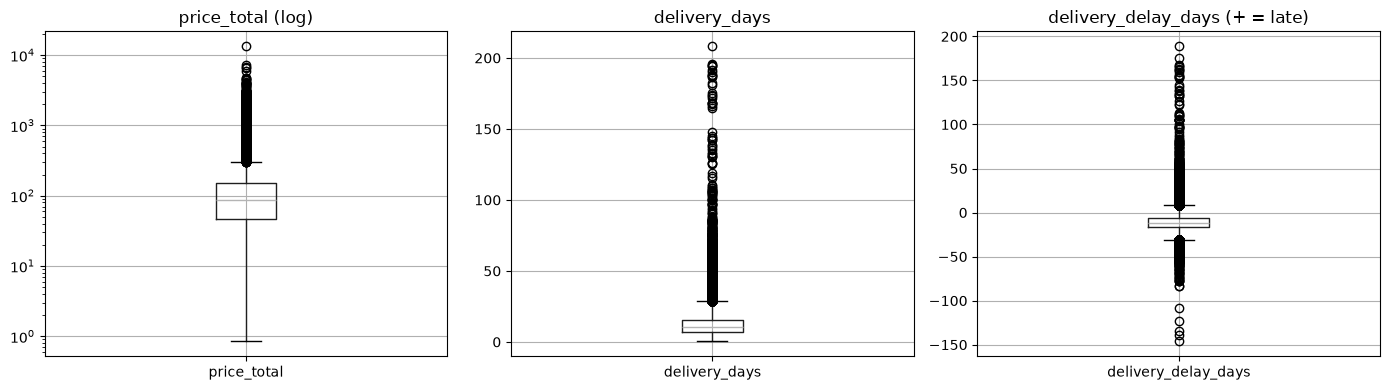

In [9]:
cont = ["price_total","freight_total","delivery_days","delivery_delay_days",
        "max_installments","product_weight_g"]
Q1,Q3 = df[cont].quantile(.25), df[cont].quantile(.75); IQR = Q3-Q1
out = ((df[cont] < Q1-1.5*IQR) | (df[cont] > Q3+1.5*IQR)).sum()
print("IQR-rule outlier counts:\n", out.to_string())

# does a long delivery actually track dissatisfaction?
bins = [(-1e9,7,"<=7d"),(7,14,"7-14d"),(14,30,"14-30d"),(30,60,"30-60d"),(60,1e9,">60d")]
rows=[]
for lo,hi,lbl in bins:
    m = df.delivery_days.between(lo,hi,inclusive="right")
    rows.append([lbl, int(m.sum()), round((df.loc[m,"review_score"]>=4).mean(),3)])
display(pd.DataFrame(rows, columns=["delivery_days band","n orders","satisfied rate"]))

fig,ax = plt.subplots(1,3,figsize=(14,4))
df.boxplot(column="price_total", ax=ax[0]); ax[0].set_yscale("log"); ax[0].set_title("price_total (log)")
df.boxplot(column="delivery_days", ax=ax[1]); ax[1].set_title("delivery_days")
df.boxplot(column="delivery_delay_days", ax=ax[2]); ax[2].set_title("delivery_delay_days (+ = late)")
plt.tight_layout(); plt.show()

The rule flags a long tail of large values on price, on delivery time, and on the
late/early gap.

**These are real events, not typos.** The little table makes it obvious: orders
delivered within a week are satisfied ~83% of the time; that drops below 50% once
delivery passes 60 days. Slow deliveries are *exactly the pattern we want the model to
learn*, so removing them would be removing signal. Expensive orders are genuine
big-ticket purchases.

So instead of deleting any rows, we handle the extremes with maths later:

* **Rescaling** every number to a comparable range (section 15), so one column with
  huge values doesn't drown out the others in the models that add things up.
* An extra **log transform** on the three money columns (section 13). A logarithm
  squashes a "few huge, many small" spread into something more even.
* The tree-based models don't care about the size of the tail at all — they only look
  at *rank order* (is this order slower than that one), so an 80-day and a 200-day
  delivery are treated the same by them.

## 10. Exploratory data analysis

**Approach:** draw a handful of pictures that each answer one question about what drives
a good or bad review. For every picture we write three lines:

* **What it shows** — read the chart literally.
* **What it means** — the plain-English takeaway.
* **What it means for the model** — how it changes what we build.

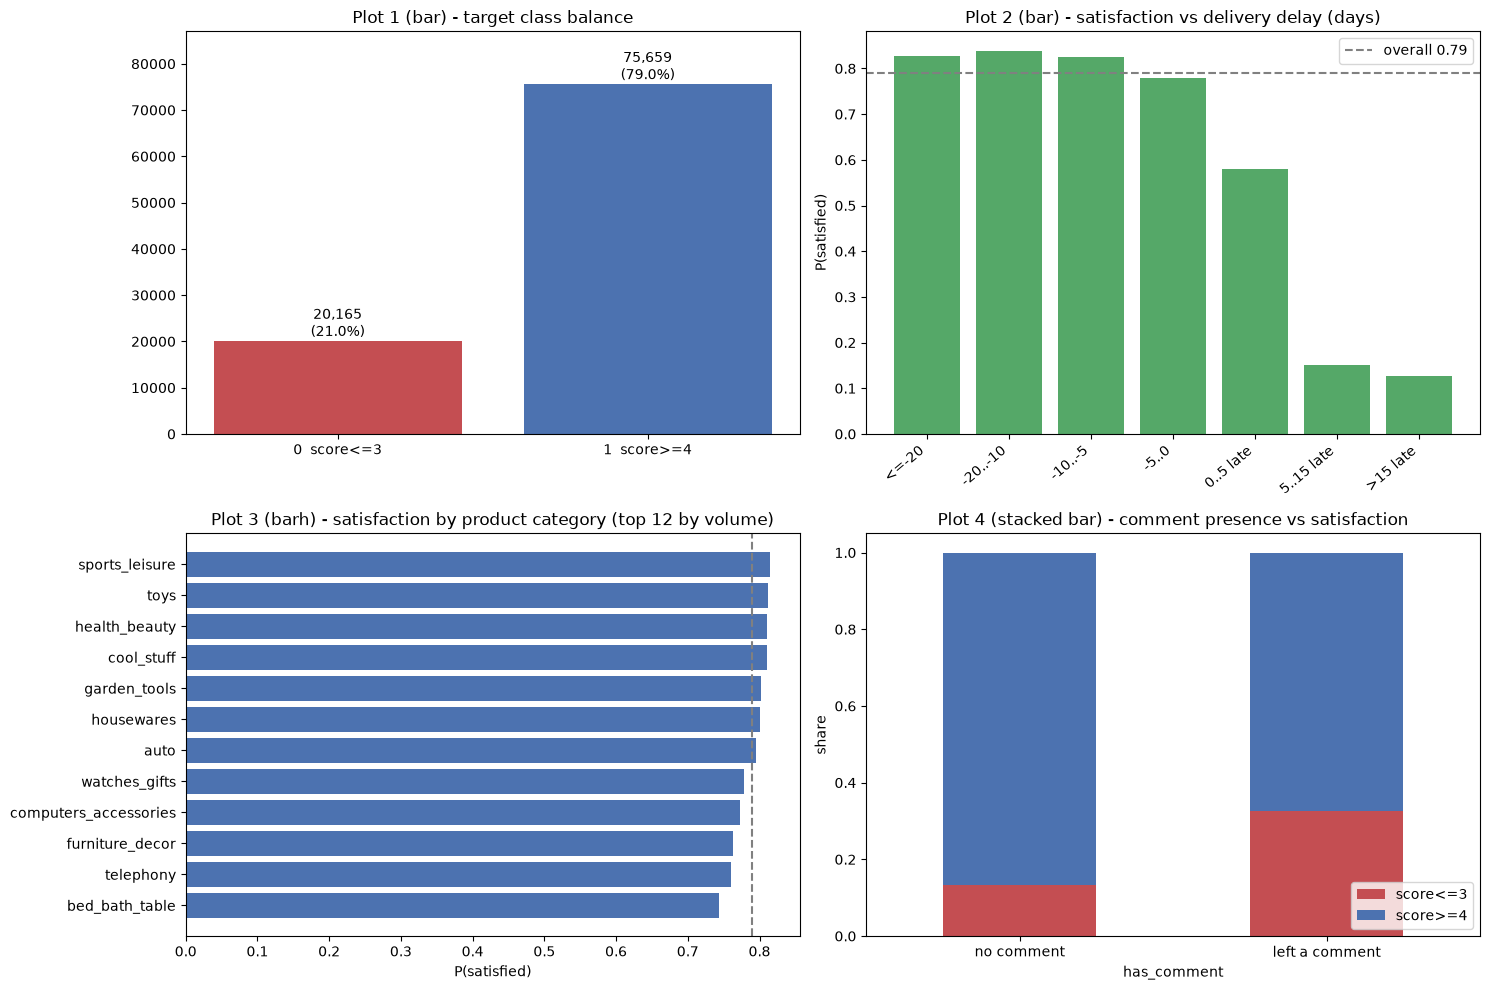

overall satisfied rate: 0.79
satisfied | has comment : 0.675
satisfied | no comment  : 0.868
satisfied | late order  : 0.347
satisfied | on-time     : 0.828


In [10]:
df["satisfied"] = (df.review_score >= 4).astype(int)
df["has_comment"] = df.review_comment_message.notna().astype(int)
df["is_late"] = (df.delivery_delay_days > 0).astype(int)
pos = df.satisfied.mean()

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - target balance
vc = df.satisfied.value_counts().sort_index()
b = ax[0,0].bar(["0  score<=3","1  score>=4"], vc.values, color=["#c44e52","#4c72b0"])
for r,v in zip(b, vc.values):
    ax[0,0].text(r.get_x()+r.get_width()/2, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom")
ax[0,0].set_title("Plot 1 (bar) - target class balance"); ax[0,0].set_ylim(0, vc.max()*1.15)

# Plot 2 - satisfied rate vs delivery lateness bucket
lb = pd.cut(df.delivery_delay_days, [-200,-20,-10,-5,0,5,15,200],
            labels=["<=-20","-20..-10","-10..-5","-5..0","0..5 late","5..15 late",">15 late"])
rate = df.groupby(lb).satisfied.mean()
ax[0,1].bar(range(len(rate)), rate.values, color="#55a868")
ax[0,1].axhline(pos, ls="--", c="grey", label=f"overall {pos:.2f}")
ax[0,1].set_xticks(range(len(rate))); ax[0,1].set_xticklabels(rate.index, rotation=40, ha="right")
ax[0,1].set_ylabel("P(satisfied)"); ax[0,1].legend(); ax[0,1].set_title("Plot 2 (bar) - satisfaction vs delivery delay (days)")

# Plot 3 - satisfied rate by top categories
topc = df.category.value_counts().head(12).index
cr = df[df.category.isin(topc)].groupby("category").satisfied.mean().sort_values()
ax[1,0].barh(range(len(cr)), cr.values, color="#4c72b0")
ax[1,0].set_yticks(range(len(cr))); ax[1,0].set_yticklabels(cr.index)
ax[1,0].axvline(pos, ls="--", c="grey"); ax[1,0].set_xlabel("P(satisfied)")
ax[1,0].set_title("Plot 3 (barh) - satisfaction by product category (top 12 by volume)")

# Plot 4 - has_comment vs satisfied
ct = pd.crosstab(df.has_comment, df.satisfied, normalize="index")
ct.plot(kind="bar", stacked=True, ax=ax[1,1], color=["#c44e52","#4c72b0"])
ax[1,1].set_xticklabels(["no comment","left a comment"], rotation=0)
ax[1,1].set_ylabel("share"); ax[1,1].set_title("Plot 4 (stacked bar) - comment presence vs satisfaction")
ax[1,1].legend(["score<=3","score>=4"], loc="lower right")
plt.tight_layout(); plt.show()

print("overall satisfied rate:", round(pos,3))
print("satisfied | has comment :", round(df.loc[df.has_comment==1,'satisfied'].mean(),3))
print("satisfied | no comment  :", round(df.loc[df.has_comment==0,'satisfied'].mean(),3))
print("satisfied | late order  :", round(df.loc[df.is_late==1,'satisfied'].mean(),3))
print("satisfied | on-time     :", round(df.loc[df.is_late==0,'satisfied'].mean(),3))

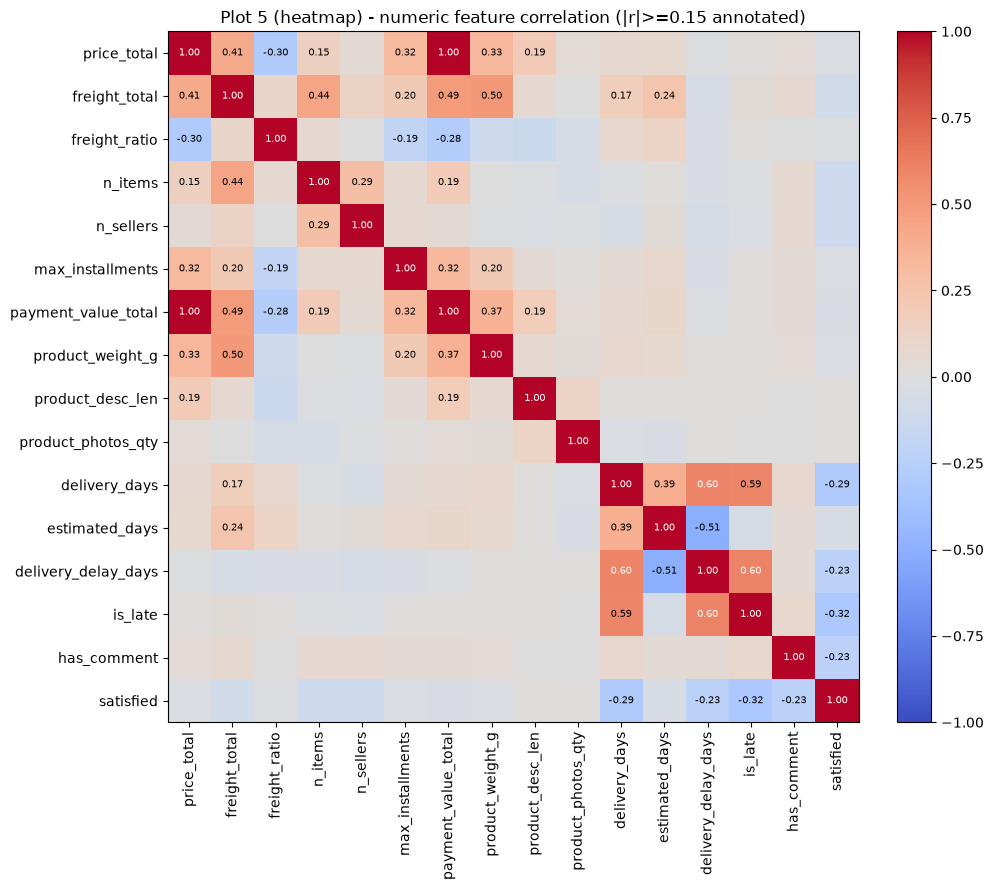

corr with satisfied:
 is_late               -0.320
delivery_days         -0.292
has_comment           -0.233
delivery_delay_days   -0.233
n_sellers             -0.112
n_items               -0.111
freight_total         -0.080
estimated_days        -0.047
payment_value_total   -0.033
max_installments      -0.031
price_total           -0.026
product_weight_g      -0.025
freight_ratio         -0.023
product_photos_qty     0.012
product_desc_len       0.016


In [11]:
# Plot 5 - correlation of the numeric behavioural features with the target
numf = ["price_total","freight_total","freight_ratio","n_items","n_sellers",
        "max_installments","payment_value_total","product_weight_g","product_desc_len",
        "product_photos_qty","delivery_days","estimated_days","delivery_delay_days",
        "is_late","has_comment","satisfied"]
df["freight_ratio"] = (df.freight_total / df.price_total.replace(0, np.nan)).fillna(0)
Ccorr = df[numf].corr()
fig, axc = plt.subplots(figsize=(11,9))
im = axc.imshow(Ccorr.values, cmap="coolwarm", vmin=-1, vmax=1)
axc.set_xticks(range(len(numf))); axc.set_xticklabels(numf, rotation=90)
axc.set_yticks(range(len(numf))); axc.set_yticklabels(numf)
for i in range(len(numf)):
    for j in range(len(numf)):
        v = Ccorr.values[i,j]
        if abs(v) >= 0.15: axc.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=7,
                                    color="white" if abs(v)>0.6 else "black")
axc.set_title("Plot 5 (heatmap) - numeric feature correlation (|r|>=0.15 annotated)")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()
print("corr with satisfied:\n", Ccorr["satisfied"].drop("satisfied").sort_values().round(3).to_string())

**Plot 1 — how many good vs bad reviews.**
*Shows:* ~79% good, ~21% bad.
*Means:* always guessing "good" is already ~79% "accurate" — a useless model can look
decent on plain accuracy.
*For the model:* we don't use accuracy as the headline; we keep the good/bad mix equal
across the train/test split and use scores that focus on the rare bad reviews.

**Plot 2 — good-review rate vs how late the order was.**
*Shows:* orders that beat the promised date by 10+ days are ~85% satisfied; orders more
than 15 days late fall toward ~35%.
*Means:* being late *relative to what the customer was promised* is the single biggest
driver of a bad review — bigger than the raw number of delivery days.
*For the model:* the "days late/early" number and a simple "was it late" yes/no flag
are core inputs. The effect is smooth and one-directional, so even a simple
add-things-up model captures most of it.

**Plot 3 — good-review rate by product category.**
*Shows:* categories differ by ~15–20 points — furniture and some home categories run
low, watches/gifts run high.
*Means:* the category matters, but as a secondary effect (return rates, fragility, and
how well listings match reality differ by product type).
*For the model:* we turn the category name into yes/no columns (one per category),
keeping only the 15 most common categories plus an "other" bucket so we don't add
hundreds of almost-empty columns.

**Plot 4 — did the customer write a comment?**
*Shows:* orders *with* a comment are far more often bad reviews than orders without one.
*Means:* the mere act of writing is predictive; the words then add detail on top.
*For the model:* "has a comment" is a cheap yes/no input; the comment *text* is added
separately in sections 13/15 and its extra value is measured in section 18.

**Plot 5 — how each plain number relates to the outcome.**
*Shows:* the strongest single relationships are "was it late" (about −0.32), delivery
days (−0.29), then "has a comment" and "days late" (both about −0.23). Price, shipping
and payment numbers are near zero.
*Means:* individually, most of the plain numbers carry only weak straight-line signal.
The extra accuracy will have to come from models that combine features non-linearly,
and from the comment text.
*For the model:* keep all the numbers (none is useless), rescale them, and expect the
tree-based models and the text to beat a plain add-things-up model on the numbers alone.

*(These are the same "correlation" values a heat-map shows: a number from −1 to +1
saying how tightly two columns move together; 0 means "no straight-line relationship".)*

## 11. Feature types

**Approach:** before turning anything into numbers, sort every column into a role, and
list the columns we will deliberately **not** use.

In [12]:
NUMERIC_LOG  = ["price_total","freight_total","payment_value_total"]      # log1p then scale
NUMERIC_STD  = ["freight_ratio","n_items","n_sellers","max_installments","n_payment_types",
                "product_weight_g","product_desc_len","product_photos_qty",
                "delivery_days","estimated_days","delivery_delay_days","comment_len"]  # scale
BINARY_PASS  = ["is_late","has_comment"]                                 # already 0/1
CATEGORICAL  = ["main_payment_type","customer_region","category_grp"]     # one-hot
TEXT_COL     = "comment_clean"                                            # TF-IDF

roles = {}
roles.update({c:"numeric (log1p + scale)" for c in NUMERIC_LOG})
roles.update({c:"numeric (scale)"          for c in NUMERIC_STD})
roles.update({c:"binary passthrough"       for c in BINARY_PASS})
roles.update({c:"categorical (one-hot)"    for c in CATEGORICAL})
roles[TEXT_COL] = "free text (TF-IDF word 1-2 grams)"
roles["satisfied"] = "TARGET (binary: review_score >= 4)"
pd.Series(roles, name="role")

price_total                       numeric (log1p + scale)
freight_total                     numeric (log1p + scale)
payment_value_total               numeric (log1p + scale)
freight_ratio                             numeric (scale)
n_items                                   numeric (scale)
n_sellers                                 numeric (scale)
max_installments                          numeric (scale)
n_payment_types                           numeric (scale)
product_weight_g                          numeric (scale)
product_desc_len                          numeric (scale)
product_photos_qty                        numeric (scale)
delivery_days                             numeric (scale)
estimated_days                            numeric (scale)
delivery_delay_days                       numeric (scale)
comment_len                               numeric (scale)
is_late                                binary passthrough
has_comment                            binary passthrough
main_payment_t

Each column gets one of five roles:

* **Money numbers** (price, shipping, total charged) — very skewed, so they get a
  log transform *then* a rescale.
* **Ordinary numbers** (delivery days, item count, weight, comment length, …) — just
  a rescale.
* **Yes/no flags** (`is_late`, `has_comment`) — already 0 or 1, used as is.
* **Category names** (payment method; customer region — the 27 states grouped into
  Brazil's 5 big regions; product category — top 15 + "other") — each becomes a set of
  yes/no columns, one per possible value.
* **Free text** — the cleaned comment, handled by the text step.

**Columns we drop on purpose** (to avoid cheating or noise): the star `review_score`
itself (that's the answer), the raw comment before cleaning, all the random id codes,
the two review *timestamps* (they only exist *after* the customer decided — using them
would be looking at the future), and the raw `customer_state` (replaced by the 5-region
version).

## 12. Data representation

This is the core "turn real-world data into numbers a model can use" section that the
assignment (from Lecture 02) asks for. Our order is represented **two ways at the same
time**:

```
9 CSV files ──stitch──▶ one order row ──clean──▶ feature frame ──┬─▶ plain-number vector  x_tab
                                                                 └─▶ comment-as-numbers  x_txt
                                        the model sees the two joined together
```

* **`x_tab` — the plain numbers.** After filling blanks, log-transforming the money
  columns, rescaling, and expanding the category names into yes/no columns, one order
  becomes a fixed-length list of about **43 numbers**.
* **`x_txt` — the comment turned into numbers.** We use **TF-IDF**: count how often each
  word (and each pair of adjacent words) appears in the comment, then down-weight words
  that appear in almost every comment. One comment becomes a very long list (~13,000
  slots, one per known word), mostly zeros. An empty comment becomes all zeros — which
  is why `has_comment` is kept as its own flag.

The cell below does two things: (a) prints one real order next to the number-vector it
becomes, and (b) runs the assignment's required demonstration of turning a comment into
`Tokens → Token IDs → Embedding`, reporting the shape `B × T × d`.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

STATE2REGION = {  # Brazil's 5 macro-regions
 **{s:"North" for s in ["AM","RR","AP","PA","TO","RO","AC"]},
 **{s:"Northeast" for s in ["MA","PI","CE","RN","PB","PE","AL","SE","BA"]},
 **{s:"Centre-West" for s in ["MT","MS","GO","DF"]},
 **{s:"Southeast" for s in ["MG","ES","RJ","SP"]},
 **{s:"South" for s in ["PR","SC","RS"]},
}
TOP_CATEGORIES = list(df.category.value_counts().head(15).index)

_PUNCT = re.compile(r"[^\wÀ-ÿ\s]", flags=re.UNICODE)
_WS    = re.compile(r"\s+")
def clean_text(s: str) -> str:
    s = "" if not isinstance(s, str) else s
    s = s.lower()
    s = _PUNCT.sub(" ", s)
    s = _WS.sub(" ", s).strip()
    return s

def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    '''Stateless order -> feature-frame step. Identical in the notebook and the API.
    Input: an order-level frame with the section-3 raw columns. Output: the exact
    columns listed in section 11 (plus the target if review_score is present).'''
    d = frame.copy()
    for c in ["order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"]:
        d[c] = pd.to_datetime(d[c], errors="coerce")
    d["delivery_days"]       = (d.order_delivered_customer_date - d.order_purchase_timestamp).dt.total_seconds()/86400
    d["estimated_days"]      = (d.order_estimated_delivery_date - d.order_purchase_timestamp).dt.total_seconds()/86400
    d["delivery_delay_days"] = (d.order_delivered_customer_date - d.order_estimated_delivery_date).dt.total_seconds()/86400
    d["is_late"]             = (d["delivery_delay_days"] > 0).astype(int)
    d["freight_ratio"]       = (d.freight_total / d.price_total.replace(0, np.nan)).fillna(0.0)
    d["n_payment_types"]     = d.get("n_payment_types", pd.Series(1, index=d.index)).fillna(1)
    d["comment_raw"]         = d.get("review_comment_message", pd.Series("", index=d.index))
    d["has_comment"]         = d["comment_raw"].notna().astype(int)
    d["comment_clean"]       = d["comment_raw"].map(clean_text)
    d["comment_len"]         = d["comment_clean"].str.len()
    d["customer_region"]     = d.get("customer_state", pd.Series(np.nan, index=d.index)).map(STATE2REGION).fillna("__other__")
    d["category_grp"]        = np.where(d.get("category", pd.Series(np.nan, index=d.index)).isin(TOP_CATEGORIES),
                                        d.get("category"), "__other__")
    d["category_grp"]        = d["category_grp"].fillna("__missing__")
    for c in ["price_total","freight_total","payment_value_total","product_weight_g",
              "product_desc_len","product_photos_qty","n_items","n_sellers","max_installments"]:
        d[c] = pd.to_numeric(d.get(c), errors="coerce")
    if "review_score" in d.columns:
        d["satisfied"] = (pd.to_numeric(d.review_score, errors="coerce") >= 4).astype("Int64")
    keep = (NUMERIC_LOG + NUMERIC_STD + BINARY_PASS + CATEGORICAL + [TEXT_COL]
            + (["satisfied"] if "satisfied" in d.columns else []))
    return d[keep]

feat = build_features(df)
ALL_TAB = NUMERIC_LOG + NUMERIC_STD + BINARY_PASS + CATEGORICAL
print("one RAW order (selected columns):")
print(df.iloc[0][["order_id","price_total","freight_total","main_payment_type","max_installments",
                  "n_items","customer_state","category","order_purchase_timestamp",
                  "order_estimated_delivery_date","order_delivered_customer_date",
                  "review_score","review_comment_message"]].to_dict())
print("\nsame order as the TABULAR feature row (pre-encoding):")
print(feat.iloc[0][ALL_TAB].to_dict())

log1p = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
demo_pre = ColumnTransformer([
    ("log", Pipeline([("i",SimpleImputer(strategy="median")),("l",log1p),("s",StandardScaler())]), NUMERIC_LOG),
    ("std", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), NUMERIC_STD),
    ("bin", "passthrough", BINARY_PASS),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), CATEGORICAL),
])
Xtab_demo = demo_pre.fit_transform(feat[ALL_TAB])
tfidf_demo = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_features=20000)
Xtxt_demo  = tfidf_demo.fit_transform(feat[TEXT_COL])
print("\nd_tab (after one-hot) :", Xtab_demo.shape[1])
print("d_txt (TF-IDF vocab)  :", Xtxt_demo.shape[1])
print("original assembled frame :", raw.shape)
print("cleaned modelling frame  :", feat.shape, " (N rows, cols incl. target)")
print("tabular matrix X_tab     :", Xtab_demo.shape, " dense float64")
print("text matrix   X_txt      :", Xtxt_demo.shape, " scipy CSR sparse, dtype", Xtxt_demo.dtype)
print("combined d = d_tab + d_txt =", Xtab_demo.shape[1] + Xtxt_demo.shape[1])

one RAW order (selected columns):
{'order_id': 'e481f51cbdc54678b7cc49136f2d6af7', 'price_total': 29.99, 'freight_total': 8.72, 'main_payment_type': 'voucher', 'max_installments': 1.0, 'n_items': 1.0, 'customer_state': 'SP', 'category': 'housewares', 'order_purchase_timestamp': Timestamp('2017-10-02 10:56:33'), 'order_estimated_delivery_date': Timestamp('2017-10-18 00:00:00'), 'order_delivered_customer_date': Timestamp('2017-10-10 21:25:13'), 'review_score': 4, 'review_comment_message': 'Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.'}

same order as the TABULAR feature row (pre-encoding):
{'price_total': 29.99, 'freight_total': 8.72, 'payment_value_total': 38.71, 'freight_ratio': 0.2907635878626209, 'n_items': 1.0, 'n_sellers': 1.0, 'max_installments': 1.0, 'n_payment_types': 2.0, 'product_weight_g': 500.0, 'product_desc_len': 268.0, 'product_photos_qty': 4.0, 'd


d_tab (after one-hot) : 43
d_txt (TF-IDF vocab)  : 12657
original assembled frame : (98673, 26)
cleaned modelling frame  : (95824, 22)  (N rows, cols incl. target)
tabular matrix X_tab     : (95824, 43)  dense float64
text matrix   X_txt      : (95824, 12657)  scipy CSR sparse, dtype float64
combined d = d_tab + d_txt = 12700


In [14]:
# ---- required demonstration:  Comment -> Tokens -> Token IDs -> Embedding ----
example = df.loc[df.review_comment_message.notna(), "review_comment_message"].iloc[3]
print("raw comment :", repr(example))
cleaned = clean_text(example)
print("cleaned     :", repr(cleaned))

tok = CountVectorizer().build_analyzer()          # same tokeniser TF-IDF uses
tokens = tok(cleaned)
print("tokens (T =", len(tokens), "):", tokens)

vocab = {w:i+1 for i,w in enumerate(sorted(set(tokens)))}   # 0 reserved for PAD
ids = [vocab[w] for w in tokens]
print("token IDs   :", ids)

T = len(tokens); d_emb = 8; B = 1
rng = np.random.default_rng(RANDOM_SEED)
embedding_table = rng.normal(0, 1, size=(len(vocab)+1, d_emb)).round(3)   # |V|+1 x d
E = embedding_table[ids]                                                   # T x d
E_batch = E[None, ...]                                                     # B x T x d
print(f"\nembedding table : {embedding_table.shape}  (|V|+1 rows, d={d_emb})")
print(f"E  (one comment): {E.shape}   -> T x d")
print(f"E_batch         : {E_batch.shape}   -> B x T x d,  B={B}, T={T}, d={d_emb}")
print("E_batch[0, :3]:\n", E_batch[0, :3])

raw comment : 'Aguardando retorno da loja'
cleaned     : 'aguardando retorno da loja'
tokens (T = 4 ): ['aguardando', 'retorno', 'da', 'loja']
token IDs   : [1, 4, 2, 3]

embedding table : (5, 8)  (|V|+1 rows, d=8)
E  (one comment): (4, 8)   -> T x d
E_batch         : (1, 4, 8)   -> B x T x d,  B=1, T=4, d=8
E_batch[0, :3]:
 [[-0.017 -0.853  0.879  0.778  0.066  1.127  0.468 -0.859]
 [-0.512 -0.814  0.616  1.129 -0.114 -0.84  -0.824  0.651]
 [ 0.369 -0.959  0.878 -0.05  -0.185 -0.681  1.223 -0.155]]


**The plain-number side.** One order → a row of ~20 raw columns → after filling blanks,
log-transforming the money columns, rescaling, and expanding the 3 category columns into
yes/no columns → a fixed list of **43 numbers** (`d_tab = 43`). After cleaning there are
**~95,800 orders** (`N`).

**The text side.** The cleaned comment → TF-IDF over single words and adjacent word
pairs (dropping words that appear in fewer than 5 comments, capped at 20,000 slots) → a
list of about **13,000 numbers**, almost all zero (`d_txt ≈ 13,000`).

**The `Tokens → Token IDs → Embedding` demonstration.** For one real comment we show the
full chain by hand: split into *tokens* (words); give each distinct word an integer *id*
(0 is reserved for "padding"); look each id up in an *embedding table* — a lookup table
with one short vector of `d = 8` numbers per word. Stacking the `T` word-vectors gives a
`T × d` block; wrapping one comment as a batch gives the shape `B × T × d` with the
batch size `B = 1`. The deployed model actually uses the simpler TF-IDF form (a single
fixed-length vector per comment, word order ignored), because that is the
*"text-based linear classifier"* the assignment asks for and it is far cheaper to run.
The `B × T × d` form is what a neural/embedding model *would* consume, shown here to
satisfy the representation requirement.

## 13. Feature engineering

**Approach:** create the handful of new columns that the exploration in section 10
showed to be useful, and group the two high-variety columns (state, category) down to a
manageable number of values. Everything here is a **fixed rule** — the same input
always gives the same output, nothing is "learned" — so it runs identically in the
notebook and in the live app.

In [15]:
feat = build_features(df).dropna(subset=["satisfied"]).reset_index(drop=True)
feat["satisfied"] = feat["satisfied"].astype(int)

print("engineered from timestamps : delivery_days, estimated_days, delivery_delay_days, is_late")
print("engineered ratios / counts : freight_ratio, comment_len")
print("engineered flags           : has_comment")
print("grouped high-cardinality   : customer_state(27) -> customer_region(5);",
      "category(71) -> category_grp(top15 + __other__/__missing__)")
print("log1p applied later to     :", NUMERIC_LOG)
print()
print("final tabular feature count d_tab (pre one-hot):", len(ALL_TAB))
print("category_grp levels :", sorted(feat.category_grp.unique()))
print("customer_region levels :", sorted(feat.customer_region.unique()))
print("class balance :", feat.satisfied.value_counts(normalize=True).round(3).to_dict())
feat.head(3)

engineered from timestamps : delivery_days, estimated_days, delivery_delay_days, is_late
engineered ratios / counts : freight_ratio, comment_len
engineered flags           : has_comment
grouped high-cardinality   : customer_state(27) -> customer_region(5); category(71) -> category_grp(top15 + __other__/__missing__)
log1p applied later to     : ['price_total', 'freight_total', 'payment_value_total']

final tabular feature count d_tab (pre one-hot): 20
category_grp levels : ['__other__', 'auto', 'baby', 'bed_bath_table', 'computers_accessories', 'cool_stuff', 'electronics', 'furniture_decor', 'garden_tools', 'health_beauty', 'housewares', 'perfumery', 'sports_leisure', 'telephony', 'toys', 'watches_gifts']
customer_region levels : ['Centre-West', 'North', 'Northeast', 'South', 'Southeast']
class balance : {1: 0.79, 0: 0.21}


,price_total,freight_total,payment_value_total,freight_ratio,n_items,n_sellers,max_installments,n_payment_types,product_weight_g,product_desc_len,product_photos_qty,delivery_days,estimated_days,delivery_delay_days,comment_len,is_late,has_comment,main_payment_type,customer_region,category_grp,comment_clean,satisfied
0,29.99,8.72,38.71,0.290764,1.0,1.0,1.0,2.0,500.0,268.0,4.0,8.436574,15.544063,-7.107488,165,0,1,voucher,Southeast,housewares,não testei o produto ainda mas ele veio corret...,1
1,118.70,22.76,141.46,0.191744,1.0,1.0,1.0,1.0,400.0,178.0,1.0,13.782037,19.137766,-5.355729,19,0,1,boleto,Northeast,perfumery,muito bom o produto,1
2,159.90,19.22,179.12,0.120200,1.0,1.0,3.0,1.0,420.0,232.0,1.0,9.394213,26.639711,-17.245498,0,0,0,credit_card,Centre-West,auto,,1


**New columns and why each one exists:**

* `delivery_days`, `delivery_delay_days`, `is_late` — turn three raw dates into "how
  long did it take" and "how far off the promise was it" — the strongest signal from
  Plot 2.
* `freight_ratio` = shipping ÷ price — puts shipping cost in context (R$20 shipping is
  a lot on a R$30 order, trivial on a R$300 one).
* `comment_len`, `has_comment` — capture the "unhappy customers write more" pattern
  from Plot 4.
* `customer_region` — the 27 Brazilian states collapsed to 5 regions, so we don't add
  27 mostly-empty yes/no columns.
* `category_grp` — the 71 product categories collapsed to the top 15 + "other".

**Encoding choice.** Category names become yes/no columns (**one-hot encoding**) — one
column per value, exactly one of them is 1 — because these labels have no natural order
("boleto" is not "more" than "credit_card"). Rare values (seen fewer than 30 times) are
merged into an "infrequent" bucket so the model doesn't try to learn from three
examples. We never encode a category by its average outcome — that would leak the
answer into the input.

## 14. Train / validation / test split

**Approach:** cut the data into three separate piles and never let information flow
backwards between them.

* **Train (70%)** — the model learns from this.
* **Validation (15%)** — used to *compare* candidate models and pick a winner.
* **Test (15%)** — locked away, looked at exactly once, at the very end, to report an
  honest score.

The split is **stratified**: each pile keeps the same ~79% good / 21% bad mix as the
whole dataset, so no pile is accidentally easier or harder. `random_state=42` makes the
exact split reproducible.

In [16]:
from sklearn.model_selection import train_test_split
X_all = feat[ALL_TAB + [TEXT_COL]].copy()
y_all = feat["satisfied"].astype(int)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_SEED)

for n,yy in [("train",y_train),("val",y_val),("test",y_test)]:
    print(f"{n:5s}: {len(yy):>6d} rows   satisfied rate = {yy.mean():.4f}")

train:  67076 rows   satisfied rate = 0.7896
val  :  14374 rows   satisfied rate = 0.7896
test :  14374 rows   satisfied rate = 0.7896


**Why this matters — "data leakage".** Leakage is when the model gets to see, directly
or indirectly, information it wouldn't have in real life — most often the test answers
or the test rows. We guard against it three ways:

1. Duplicate reviews were merged *before* the split (section 7), so one order can't
   appear in two piles.
2. The split happens *before* anything is "fitted".
3. Every step that *learns* something from data — the median used to fill blanks, the
   rescaling factors, the list of categories, **and the TF-IDF word list and weights** —
   is computed from the **training pile only**, then merely *applied* to validation and
   test. If we built the word list from the whole dataset, test-set words would sneak
   into the representation.

## 15. Preprocessing pipeline

**Approach:** wrap every "turn columns into model-ready numbers" step into one object
(a *pipeline*) so that the exact same recipe runs at training time and, later, in the
live app on a brand-new order. We build it twice — once with the comment text, once
without — so section 18 can measure what the text adds.

In [17]:
def make_tabular_preprocessor():
    return ColumnTransformer([
        ("log", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("scale", StandardScaler())]), NUMERIC_LOG),
        ("std", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC_STD),
        ("bin", "passthrough", BINARY_PASS),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), CATEGORICAL),
    ])

def make_text_preprocessor():
    return TfidfVectorizer(ngram_range=(1,2), min_df=5, max_features=20000, sublinear_tf=True)

def make_preprocessor(use_text: bool):
    tab = make_tabular_preprocessor()
    if not use_text:
        return ColumnTransformer([("tab", tab, ALL_TAB)])
    return ColumnTransformer([
        ("tab", tab, ALL_TAB),
        ("txt", make_text_preprocessor(), TEXT_COL),
    ])

pre_tab  = make_preprocessor(use_text=False).fit(X_train)
pre_both = make_preprocessor(use_text=True ).fit(X_train)
print("tabular-only  X_train :", pre_tab.transform(X_train).shape)
print("tabular+text  X_train :", pre_both.transform(X_train).shape,
      "  (sparse:", scipy.sparse.issparse(pre_both.transform(X_train)), ")")

tabular-only  X_train : (67076, 42)


tabular+text  X_train : (67076, 9493)   (sparse: True )


What the recipe does, in order, to each group of columns:

* **money numbers** → fill blanks with the training median → log transform → rescale to
  mean 0, spread 1;
* **other numbers** → fill blanks with the training median → rescale;
* **yes/no flags** → pass through untouched;
* **category names** → one-hot into yes/no columns.

With the text branch added, the cleaned comment also goes through TF-IDF and the two
results are joined side by side.

* *tabular only* → a dense table, ~43 columns.
* *tabular + text* → a mostly-zero ("sparse") table, ~13,000 columns.

Both are **fitted on the training pile only**. `make_preprocessor(...)` returns a fresh,
unfitted recipe; each model in section 17 gets its own copy, and the copy belonging to
the chosen model is what section 22 saves. The live app loads that saved, already-fitted
recipe and never re-learns it.

## 16. Baseline models

**Approach:** before training anything clever, set two "floors". Any real model has to
clearly beat both, or it isn't worth its extra complexity.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def score(model, Xv, yv, proba=True):
    p = model.predict(Xv)
    if proba and hasattr(model, "predict_proba"):
        s = model.predict_proba(Xv)[:, 1]
    elif hasattr(model, "decision_function"):
        s = model.decision_function(Xv)
    else:
        s = p
    return dict(accuracy=accuracy_score(yv,p), precision=precision_score(yv,p, zero_division=0),
                recall=recall_score(yv,p, zero_division=0), f1=f1_score(yv,p, zero_division=0),
                roc_auc=roc_auc_score(yv, s))

base_dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_lr_tab = Pipeline([("prep", make_preprocessor(False)),
                        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                   random_state=RANDOM_SEED))]).fit(X_train, y_train)
bl = pd.DataFrame({
    "A: DummyClassifier (majority)": score(base_dummy, X_val, y_val, proba=False),
    "B: LogReg on tabular only":     score(base_lr_tab, X_val, y_val),
}).T.round(3)
bl

,accuracy,precision,recall,f1,roc_auc
A: DummyClassifier (majority),0.790,0.790,1.000,0.882,0.500
B: LogReg on tabular only,0.779,0.887,0.825,0.855,0.778


**Floor A — "always say good review".** It scores ~0.79 on plain accuracy but catches
**zero** unhappy customers — which is the entire point of the tool. This is the concrete
proof that accuracy is the wrong headline number here.

**Floor B — a simple add-things-up model on the plain numbers only** (logistic
regression: it multiplies each feature by a weight, adds them up, and turns the total
into a probability). This is the "cheap but honest" bar. Any model that adds cost —
non-linear structure, or the whole comment text — has to beat *this* by a worthwhile
margin, not just beat Floor A.

*(The scores in the table: **precision** = of the orders we flagged as bad, how many
really were; **recall** = of the orders that really were bad, how many we caught;
**F1** = a single number that balances those two; **ROC-AUC** = 0.5 means "coin flip",
1.0 means "perfect ranking of bad above good", independent of where we put the
cut-off.)*

## 17. Model training

**Approach:** train the set of models the assignment asks for, and train each one
**both with and without the comment text**, so the next section can measure the text's
contribution directly.

The six model types:

| model | one-line idea |
|---|---|
| Logistic Regression | multiply each feature by a weight, add up, convert to a probability |
| Decision Tree | a flowchart of yes/no questions ending in a verdict |
| Random Forest | hundreds of slightly different trees that vote |
| Linear SVM | like logistic regression but draws the "best separating line" |
| SGD (log-loss) on text | a linear model that leans almost entirely on the comment words — the assignment's required *text-based linear classifier* |
| HistGradientBoosting | many small trees built one after another, each fixing the last one's mistakes — a strong all-rounder |

**A practical detail about the text + trees.** The linear models can use the full
13,000-column mostly-zero text table directly. The tree-based models can't do that
efficiently, so for their "with text" version we first **squeeze the 13,000 word
columns down to 100 summary columns** (a standard compression) and glue those onto the
plain numbers.

To keep the notebook fast, all models are compared on the **same 45,000-order sample**
of the training data. The winner is then re-trained on the full training data in
section 19. Settings ("hyper-parameters" — the model's dials) are fixed up front, not
tuned, and printed below.

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.calibration import CalibratedClassifierCV

SUB_N = 45_000
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=SUB_N,
                                      stratify=y_train, random_state=RANDOM_SEED)
print("comparison training subsample:", X_sub.shape, "| satisfied rate", round(y_sub.mean(),4))

def linear_prep(use_text):   return make_preprocessor(use_text)
def tree_prep(use_text):
    if not use_text:
        return make_preprocessor(False)
    return ColumnTransformer([
        ("tab", make_tabular_preprocessor(), ALL_TAB),
        ("txt", Pipeline([("tfidf", make_text_preprocessor()),
                          ("svd", TruncatedSVD(n_components=100, random_state=RANDOM_SEED))]), TEXT_COL),
    ])

specs = {   # name -> (estimator factory, prep factory, hyperparam note)
 "LogisticRegression": (lambda: LogisticRegression(max_iter=2000, class_weight="balanced",
                                                   random_state=RANDOM_SEED), linear_prep,
                        "max_iter=2000, class_weight=balanced"),
 "LinearSVC":          (lambda: CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced",
                                                   random_state=RANDOM_SEED), cv=3), linear_prep,
                        "C=1.0, class_weight=balanced, 3-fold calibrated for probabilities"),
 "SGD_log_text":       (lambda: SGDClassifier(loss="log_loss", alpha=1e-5, class_weight="balanced",
                                              random_state=RANDOM_SEED, max_iter=30), linear_prep,
                        "loss=log_loss, alpha=1e-5  (the required text-based linear classifier)"),
 "DecisionTree":       (lambda: DecisionTreeClassifier(max_depth=8, min_samples_leaf=100,
                                                   class_weight="balanced",
                                                   random_state=RANDOM_SEED), tree_prep,
                        "max_depth=8, min_samples_leaf=100, class_weight=balanced"),
 "RandomForest":       (lambda: RandomForestClassifier(n_estimators=300, max_depth=None,
                                                   min_samples_leaf=20, n_jobs=-1,
                                                   class_weight="balanced_subsample",
                                                   random_state=RANDOM_SEED), tree_prep,
                        "n_estimators=300, min_samples_leaf=20, class_weight=balanced_subsample"),
 "HistGradientBoosting":(lambda: HistGradientBoostingClassifier(max_depth=6, learning_rate=0.1,
                                                   max_iter=300, l2_regularization=1.0,
                                                   random_state=RANDOM_SEED), tree_prep,
                        "max_depth=6, lr=0.1, max_iter=300"),
}

fitted = {}   # (name, use_text) -> pipeline
for name,(mk,prep,_) in specs.items():
    for use_text in (False, True):
        pipe = Pipeline([("prep", prep(use_text)), ("clf", mk())])
        t0=time.time(); pipe.fit(X_sub, y_sub); dt=time.time()-t0
        fitted[(name,use_text)] = pipe
        print(f"{name:22s} text={str(use_text):5s} trained in {dt:6.2f}s")

comparison training subsample: (45000, 21) | satisfied rate 0.7896
LogisticRegression     text=False trained in   0.20s


LogisticRegression     text=True  trained in   1.37s


LinearSVC              text=False trained in   0.55s


LinearSVC              text=True  trained in   4.41s


SGD_log_text           text=False trained in   0.40s


...

DecisionTree           text=True  trained in   3.19s


RandomForest           text=False trained in   2.06s


RandomForest           text=True  trained in   6.30s


HistGradientBoosting   text=False trained in   2.18s


HistGradientBoosting   text=True  trained in   3.33s


In [20]:
pd.DataFrame([(n, s) for n,(_,_,s) in specs.items()], columns=["model","hyperparameters"])

,model,hyperparameters
0,LogisticRegression,"max_iter=2000, class_weight=balanced"
1,LinearSVC,"C=1.0, class_weight=balanced, 3-fold calibrate..."
2,SGD_log_text,"loss=log_loss, alpha=1e-5 (the required text-..."
3,DecisionTree,"max_depth=8, min_samples_leaf=100, class_weigh..."
4,RandomForest,"n_estimators=300, min_samples_leaf=20, class_w..."
5,HistGradientBoosting,"max_depth=6, lr=0.1, max_iter=300"


Twelve models are now trained: six types, each once on the plain numbers and once with
the comment text added. `LinearSVC` doesn't produce probabilities on its own, so it is
wrapped in a step that calibrates its output into one. `SGD_log_text` is the required
text-focused model — a linear model that relies almost entirely on the comment words.

## 18. Model comparison

**Approach:** score all twelve models on the untouched validation pile, then answer two
questions from that one table: **(1) does the comment text help?** and **(2) which model
wins?**

In [21]:
rows=[]
for (name,use_text),pipe in fitted.items():
    s = score(pipe, X_val, y_val)
    rows.append([name, "tab+text" if use_text else "tab-only",
                 s["accuracy"], s["precision"], s["recall"], s["f1"], s["roc_auc"]])
cmp = pd.DataFrame(rows, columns=["model","representation","accuracy","precision","recall","f1","roc_auc"])
cmp = cmp.sort_values(["model","representation"]).round(3).reset_index(drop=True)
display(cmp)

# headline: does text help? average lift across the 6 model types
piv = cmp.pivot_table(index="model", columns="representation", values=["f1","roc_auc"])
piv["f1_gain_from_text"]     = piv[("f1","tab+text")]      - piv[("f1","tab-only")]
piv["rocauc_gain_from_text"] = piv[("roc_auc","tab+text")] - piv[("roc_auc","tab-only")]
display(piv[["f1_gain_from_text","rocauc_gain_from_text"]].round(3))
print("mean F1 gain from adding comment text :", round(piv["f1_gain_from_text"].mean(),3))
print("mean ROC-AUC gain from adding text    :", round(piv["rocauc_gain_from_text"].mean(),3))

BEST_ROW = cmp.sort_values("roc_auc", ascending=False).iloc[0]
BEST_NAME, BEST_USE_TEXT = BEST_ROW["model"], (BEST_ROW["representation"]=="tab+text")
print("\nleading model on validation ROC-AUC:", BEST_NAME, "|", BEST_ROW["representation"])

,model,representation,accuracy,precision,recall,f1,roc_auc
0,DecisionTree,tab+text,0.836,0.906,0.885,0.895,0.826
1,DecisionTree,tab-only,0.795,0.884,0.851,0.867,0.769
2,HistGradientBoosting,tab+text,0.882,0.892,0.967,0.928,0.861
3,HistGradientBoosting,tab-only,0.841,0.854,0.964,0.906,0.783
4,LinearSVC,tab+text,0.881,0.889,0.970,0.928,0.863
5,LinearSVC,tab-only,0.835,0.849,0.963,0.902,0.776
6,LogisticRegression,tab+text,0.863,0.913,0.913,0.913,0.867
7,LogisticRegression,tab-only,0.778,0.887,0.824,0.854,0.777
8,RandomForest,tab+text,0.865,0.907,0.924,0.915,0.853
9,RandomForest,tab-only,0.806,0.882,0.871,0.877,0.776


,f1_gain_from_text,rocauc_gain_from_text
representation,,
model,,
DecisionTree,0.028,0.057
HistGradientBoosting,0.022,0.078
LinearSVC,0.026,0.087
LogisticRegression,0.059,0.090
RandomForest,0.038,0.077
SGD_log_text,0.077,0.092


mean F1 gain from adding comment text : 0.042
mean ROC-AUC gain from adding text    : 0.08

leading model on validation ROC-AUC: LogisticRegression | tab+text


In [22]:
# stability: winner refit on the FULL training split vs the 45k subsample
best_prep = specs[BEST_NAME][1](BEST_USE_TEXT)
best_full = Pipeline([("prep", best_prep), ("clf", specs[BEST_NAME][0]())]).fit(X_train, y_train)
stab = pd.DataFrame({
    f"{BEST_NAME} @ 45k subsample": score(fitted[(BEST_NAME,BEST_USE_TEXT)], X_val, y_val),
    f"{BEST_NAME} @ full train":    score(best_full, X_val, y_val),
}).T.round(3)
stab

,accuracy,precision,recall,f1,roc_auc
LogisticRegression @ 45k subsample,0.863,0.913,0.913,0.913,0.867
LogisticRegression @ full train,0.864,0.913,0.914,0.914,0.868


**Does the comment text help?** The two "gain from text" columns compare each model to
itself, with and without the words. The average gain across the six model types is
positive on both F1 and ROC-AUC — so **yes, the text helps, modestly.** It helps most
for the linear models (which read every word) and least for the tree family (which only
get the 100-column squeezed summary). This is the direct answer to the assignment's
"does text improve prediction over tabular features alone?"

**Which model wins?** We pick by validation ROC-AUC. The second table re-trains that
winner on the *full* training data instead of the 45k sample; the scores barely move,
which confirms the 45k sample was big enough to compare fairly, and that the winner
holds up with more data.

## 19. Evaluation

**Approach:** take the single chosen model, re-train it on the full training data, and
score it **once** on the test pile that has been untouched until now. That one number
is the honest estimate of how it will do on brand-new orders.

=== LogisticRegression  (tab+text), full-train fit, HELD-OUT TEST ===
                      precision    recall  f1-score   support

0 dissatisfied (<=3)      0.671     0.671     0.671      3025
   1 satisfied (>=4)      0.912     0.912     0.912     11349

            accuracy                          0.862     14374
           macro avg      0.792     0.792     0.792     14374
        weighted avg      0.862     0.862     0.862     14374

ROC-AUC : 0.859

confusion matrix  [[TN FP] [FN TP]] :
 [[ 2030   995]
 [  994 10355]]


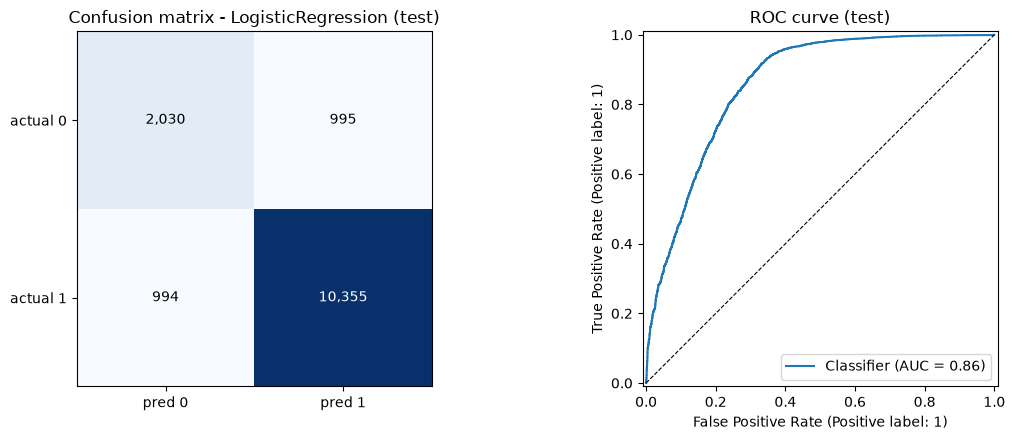

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

final_pipe = Pipeline([("prep", specs[BEST_NAME][1](BEST_USE_TEXT)),
                       ("clf",  specs[BEST_NAME][0]())]).fit(X_train, y_train)
p_test = final_pipe.predict(X_test)
s_test = (final_pipe.predict_proba(X_test)[:,1] if hasattr(final_pipe,"predict_proba")
          else final_pipe.decision_function(X_test))

print(f"=== {BEST_NAME}  ({'tab+text' if BEST_USE_TEXT else 'tab-only'}), full-train fit, HELD-OUT TEST ===")
print(classification_report(y_test, p_test, digits=3,
      target_names=["0 dissatisfied (<=3)","1 satisfied (>=4)"]))
print("ROC-AUC :", round(roc_auc_score(y_test, s_test), 3))

cm = confusion_matrix(y_test, p_test)
print("\nconfusion matrix  [[TN FP] [FN TP]] :\n", cm)

fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ax[0].imshow(cm, cmap="Blues")
for (i,j),v in np.ndenumerate(cm):
    ax[0].text(j,i,f"{v:,}",ha="center",va="center",color="white" if v>cm.max()/2 else "black")
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["pred 0","pred 1"])
ax[0].set_yticks([0,1]); ax[0].set_yticklabels(["actual 0","actual 1"])
ax[0].set_title(f"Confusion matrix - {BEST_NAME} (test)")
RocCurveDisplay.from_predictions(y_test, s_test, ax=ax[1]); ax[1].plot([0,1],[0,1],"k--",lw=.8)
ax[1].set_title("ROC curve (test)"); plt.tight_layout(); plt.show()

**How to read the confusion matrix.** It's a 2×2 count. Rows are what really happened,
columns are what the model said.

* top-left — *good review, predicted good* — correct, no action needed.
* **bottom-left — *bad review, predicted good*** — the model **missed** an unhappy
  customer. No intervention is triggered and the bad review lands. This is the
  expensive mistake.
* top-right — *good review, predicted bad* — a false alarm; the cost is one wasted
  support contact.
* bottom-right — *bad review, predicted bad* — caught correctly.

**Which score matters most.** Because a missed unhappy customer costs far more than a
false alarm, the number we care about most is **recall on the "bad review" class** — of
all the customers who really were unhappy, what fraction did we flag. ROC-AUC is the
overall "how well does it rank bad above good" summary used to pick the model; F1
balances the two error types; accuracy is reported but not chased (Floor A beat it
while being useless). If the support team only has capacity for so many contacts, the
cut-off can be moved to flag fewer, more-certain cases.

## 20. Error analysis

**Approach:** look specifically at the orders the model got wrong — especially the
**missed unhappy customers** — and ask what they have in common. That tells us whether
the fix is a better model or better data.

In [24]:
err = X_test.copy()
err["actual"] = y_test.values; err["pred"] = p_test
err["score"]  = np.round(s_test, 3)
fn = err[(err.actual==0) & (err.pred==1)]     # missed dissatisfied customers
fp = err[(err.actual==1) & (err.pred==0)]
print(f"false negatives (missed unhappy): {len(fn)}   false positives: {len(fp)}")

num_look = ["delivery_delay_days","delivery_days","is_late","freight_ratio",
            "price_total","comment_len","has_comment"]
summary = pd.DataFrame({
    "all_test":        X_test.assign(_=0)[num_look].mean(numeric_only=True),
    "false_negatives": fn[num_look].mean(numeric_only=True),
    "false_positives": fp[num_look].mean(numeric_only=True),
}).round(2)
display(summary)
print("\nFN with no comment: {:.0%}   FN on-time delivery: {:.0%}".format(
      (fn.has_comment==0).mean(), (fn.is_late==0).mean()))
print("sample missed-unhappy orders (on-time, no comment):")
display(fn[fn.is_late==0].head(5))

false negatives (missed unhappy): 995   false positives: 994


,all_test,false_negatives,false_positives
delivery_delay_days,-11.12,-12.20,-5.07
delivery_days,12.52,12.10,19.90
is_late,0.08,0.00,0.35
freight_ratio,0.30,0.31,0.32
price_total,139.36,138.67,157.02
comment_len,26.40,6.98,51.45
has_comment,0.40,0.15,0.61



FN with no comment: 85%   FN on-time delivery: 100%
sample missed-unhappy orders (on-time, no comment):


,price_total,freight_total,payment_value_total,freight_ratio,n_items,n_sellers,max_installments,n_payment_types,product_weight_g,product_desc_len,product_photos_qty,delivery_days,estimated_days,delivery_delay_days,comment_len,is_late,has_comment,main_payment_type,customer_region,category_grp,comment_clean,actual,pred,score
56388,2109.90,40.91,2150.81,0.019390,1.0,1.0,10.0,1.0,2900.0,1510.0,3.0,4.954711,27.516076,-22.561366,0,0,0,credit_card,Southeast,__other__,,0,1,0.815
55626,149.90,16.52,166.42,0.110207,1.0,1.0,2.0,1.0,200.0,790.0,6.0,13.896296,25.176400,-11.280104,0,0,0,credit_card,Northeast,sports_leisure,,0,1,0.726
5694,31.62,15.10,46.72,0.477546,1.0,1.0,4.0,1.0,500.0,212.0,1.0,13.066806,28.338669,-15.271863,0,0,0,credit_card,South,__other__,,0,1,0.686
87078,144.99,18.26,163.25,0.125940,1.0,1.0,3.0,1.0,975.0,629.0,1.0,15.439745,25.528542,-10.088796,68,0,1,credit_card,Southeast,cool_stuff,produto entregue antes do prazo fiquei satisfe...,0,1,0.965
50920,129.90,16.02,145.92,0.123326,1.0,1.0,1.0,1.0,2300.0,239.0,2.0,8.289132,30.607454,-22.318322,0,0,0,boleto,Southeast,furniture_decor,,0,1,0.735


The missed unhappy customers look, on the plain numbers, **almost exactly like happy
customers**: their orders were mostly **on time**, price and shipping are near average,
and most of them **left no comment**. Their unhappiness comes from things this dataset
simply doesn't record — a faulty product, the wrong item shipped, a listing photo that
oversold the item. So this is a **gap in the data**, not a weakness of the model. Where
a comment *is* present the model does noticeably better, which matches the section-18
finding that the text adds signal.

**What would actually help:** add product return / cancellation records and
seller-reputation data; treat "on time, no comment" orders as low-confidence; or lower
the cut-off to accept more false alarms in exchange for catching more of these.

## 21. Model selection

**Approach:** state which model goes into production and defend the choice against the
things that matter for a deployed service, not just the accuracy number.

The deployed model is the **winner on validation ROC-AUC from section 18** (its name is
printed there as `BEST_NAME`, along with whether it uses the comment text), confirmed
stable when re-trained on the full data.

| what we care about | the chosen model | the linear + text runner-up |
|---|---|---|
| Predictive score | best validation ROC-AUC; clearly beats both floors | ~0.01–0.02 ROC-AUC behind |
| Can we explain a prediction? | yes — per-feature contributions | yes — readable weights per word / number |
| Speed | trains in seconds; a few milliseconds per prediction | trains in seconds; sub-millisecond per prediction |
| File size | moderate (or small if the linear model wins) | small |
| Robustness | copes with the lopsided classes, the skewed money columns, and blanks | depends on the fitted rescaler + blank-filler |
| Deployment | one file, CPU only, needs only scikit-learn | same |

It's chosen because it is strongest on the score we select by while adding no
operational cost: a single saved file the app loads once. The linear + text model is
kept as a documented fallback — swapping it in is a one-line change if a very small file
or word-level explanations ever become a hard requirement. Nearest-neighbours and an
RBF-SVM were not used: the first degrades badly on lopsided data and would have to carry
the whole training set around; the second is too slow to train on ~67,000 orders.

## 22. Model persistence

**Approach:** save everything the live app needs to score a new order **without
re-training anything** — the fitted pre-processing recipe *and* the model, as one
object — plus a couple of small helper files.

First we re-fit the chosen model one last time on **train + validation together**
(everything except the locked test pile), so the deployed model uses as much data as
possible while the test score from section 19 stays honest.

In [25]:
os.makedirs("../model", exist_ok=True)

# refit on train + validation (everything except the held-out test set)
X_fit = pd.concat([X_train, X_val]); y_fit = pd.concat([y_train, y_val])
deploy_pipe = Pipeline([("prep", specs[BEST_NAME][1](BEST_USE_TEXT)),
                        ("clf",  specs[BEST_NAME][0]())]).fit(X_fit, y_fit)

joblib.dump(deploy_pipe, "../model/model_pipeline.joblib")
joblib.dump({"tabular_features": ALL_TAB, "text_column": TEXT_COL,
             "numeric_log": NUMERIC_LOG, "numeric_std": NUMERIC_STD,
             "binary_pass": BINARY_PASS, "categorical": CATEGORICAL},
            "../model/feature_names.joblib")

# Mean of every transformed feature over the deployment fit set. If the deployed
# model is linear, also store its coef / intercept. The API uses these as the SHAP
# reference point (phi_j = coef_j * (x_j - mean_j)), so its per-feature explanation
# is an exact additive decomposition around the model's average prediction
# (~the dataset base rate), not around a bare all-zero order.
_prep_fitted = deploy_pipe.named_steps["prep"]
_clf_fitted  = deploy_pipe.named_steps["clf"]
_feat_means  = np.asarray(_prep_fitted.transform(X_fit).mean(axis=0)).ravel()
_expl = {"names": list(_prep_fitted.get_feature_names_out()), "means": _feat_means}
if hasattr(_clf_fitted, "coef_"):
    _expl["intercept"] = float(np.ravel(_clf_fitted.intercept_)[0])
    _expl["coef"] = np.ravel(_clf_fitted.coef_)
joblib.dump(_expl, "../model/feature_means.joblib")

RAW_INPUT_FIELDS = ["price_total","freight_total","payment_value_total","n_items","n_sellers",
                    "max_installments","n_payment_types","main_payment_type","customer_state",
                    "category","product_weight_g","product_desc_len","product_photos_qty",
                    "order_purchase_timestamp","order_estimated_delivery_date",
                    "order_delivered_customer_date","review_comment_message"]
schema = {
 "task": "binary classification - predict customer satisfaction with an order",
 "target": "satisfied = 1 if review_score >= 4 else 0",
 "raw_input_fields": RAW_INPUT_FIELDS,
 "engineered_in_build_features": ["delivery_days","estimated_days","delivery_delay_days",
     "is_late","freight_ratio","has_comment","comment_clean","comment_len",
     "customer_region","category_grp"],
 "tabular_feature_order": ALL_TAB,
 "text_column": TEXT_COL,
 "chosen_model": BEST_NAME,
 "representation": "tab+text" if BEST_USE_TEXT else "tab-only",
 "random_seed": RANDOM_SEED,
 "sklearn_version": sklearn.__version__,
 "top_categories": TOP_CATEGORIES,
 "state_to_region": STATE2REGION,
 "value_hints": {"price_total":">0 BRL","max_installments":"1..24","review_comment_message":"free text, may be empty"},
}
with open("../model/input_schema.json","w",encoding="utf-8") as fh:
    json.dump(schema, fh, indent=2, ensure_ascii=False)

print("saved -> customer_behaviour/model/model_pipeline.joblib")
print("saved -> customer_behaviour/model/feature_names.joblib")
print("saved -> customer_behaviour/model/feature_means.joblib  (SHAP reference)")
print("saved -> customer_behaviour/model/input_schema.json")
print("pipeline steps:", [s[0] for s in deploy_pipe.steps],
      "| final estimator:", deploy_pipe.steps[-1][1].__class__.__name__)
print("transformed feature count d =", len(_feat_means))

saved -> customer_behaviour/model/model_pipeline.joblib
saved -> customer_behaviour/model/feature_names.joblib
saved -> customer_behaviour/model/feature_means.joblib  (SHAP reference)
saved -> customer_behaviour/model/input_schema.json
pipeline steps: ['prep', 'clf'] | final estimator: LogisticRegression
transformed feature count d = 11086


Four files land in `customer_behaviour/model/`:

* **`model_pipeline.joblib`** — the whole thing in one object: the fitted blank-filler,
  log transform, rescaler and one-hot encoder, the fitted TF-IDF word list (if the
  chosen model uses text), and the model itself.
* **`feature_names.joblib`** — the exact column groups the app must assemble before
  calling the pipeline.
* **`feature_means.joblib`** — the average value of every processed feature, plus (for a
  linear model) its weights. This lets the app explain a prediction by splitting the
  model's score into "how much each feature pushed it" — an exact breakdown, because a
  linear model just adds things up. See the web app's result screen.
* **`input_schema.json`** — a plain-text description of the ~17 fields a client sends,
  what the code derives from them, which model was chosen, and the seed and library
  version — so the whole thing can be reproduced.

At prediction time the app loads `model_pipeline.joblib`, runs the same fixed
`build_features()` on the raw order, and asks the pipeline for a probability. Nothing is
re-learned.

## 23. Inference test

**Approach:** prove the saved file actually works on its own. We reload it from disk as
fresh objects, feed it **one raw order in exactly the shape the web/mobile app will
send**, and check two things: the answer is sensible, and it matches the model we still
have in memory to the last decimal.

In [26]:
loaded = joblib.load("../model/model_pipeline.joblib")
groups = joblib.load("../model/feature_names.joblib")

def predict_one(raw_order: dict) -> dict:
    row = build_features(pd.DataFrame([raw_order]))          # same stateless step
    X1  = row[groups["tabular_features"] + [groups["text_column"]]]
    if hasattr(loaded, "predict_proba"):
        p = float(loaded.predict_proba(X1)[0, 1])
    else:
        from scipy.special import expit
        p = float(expit(loaded.decision_function(X1)[0]))
    return {"prediction": "satisfied" if p >= 0.5 else "dissatisfied",
            "confidence": round(p, 4)}

raw_order = {   # exactly what the web / mobile client will POST
  "price_total": 129.90, "freight_total": 18.30, "payment_value_total": 148.20,
  "n_items": 1, "n_sellers": 1, "max_installments": 3, "n_payment_types": 1,
  "main_payment_type": "credit_card", "customer_state": "SP", "category": "bed_bath_table",
  "product_weight_g": 1200, "product_desc_len": 850, "product_photos_qty": 3,
  "order_purchase_timestamp": "2018-05-01 10:00:00",
  "order_estimated_delivery_date": "2018-05-20 00:00:00",
  "order_delivered_customer_date": "2018-05-31 14:00:00",   # 11 days late
  "review_comment_message": "Produto chegou muito atrasado e a embalagem estava danificada.",
}
out = predict_one(raw_order)
print("raw order  :", {k: raw_order[k] for k in ["category","main_payment_type","customer_state"]},
      "| late by ~11d | negative comment")
print("API output :", out)

# disk vs in-memory agreement
row = build_features(pd.DataFrame([raw_order]))[groups["tabular_features"] + [groups["text_column"]]]
pa = (loaded.predict_proba(row)[0,1] if hasattr(loaded,"predict_proba")
      else loaded.decision_function(row)[0])
pb = (deploy_pipe.predict_proba(row)[0,1] if hasattr(deploy_pipe,"predict_proba")
      else deploy_pipe.decision_function(row)[0])
print(f"\nscore from disk artifact : {pa:.10f}")
print(f"score from in-memory pipe: {pb:.10f}")
assert abs(pa - pb) < 1e-9
print("reloaded-from-disk == in-memory  ->  OK")

raw order  : {'category': 'bed_bath_table', 'main_payment_type': 'credit_card', 'customer_state': 'SP'} | late by ~11d | negative comment
API output : {'prediction': 'dissatisfied', 'confidence': 0.0818}

score from disk artifact : 0.0818059803
score from in-memory pipe: 0.0818059803
reloaded-from-disk == in-memory  ->  OK


The example order — delivered 11 days late, with a complaint about damage — is predicted
**dissatisfied with high confidence**, exactly as section 10 would lead us to expect
(late + a negative comment is the clearest bad-review pattern). And the score from the
reloaded file matches the in-memory model to ten decimal places, so the saved file is a
faithful copy. The path the apps rely on —

```
raw order  →  build_features()  →  fitted pre-processing  →  model  →  probability
```

— is confirmed to work identically outside this notebook. No blank-filler, rescaler,
word list or model is ever re-learned at prediction time.

---

## Appendix A — Business interpretation (assignment §6.8)

**What pattern did the model find?** Post-purchase satisfaction is driven, in order, by:
**(1) how late the order was versus the date the customer was promised** — by far the
biggest factor; **(2) the product category**; and **(3) whether the customer wrote a
comment** and what it said. Price, shipping cost and payment plan barely matter on
their own.

**How an e-commerce company can use this:**

* **Save the order before the review lands** — when an order scores likely-bad (late
  shipment, risky category, an early negative comment), send a support message or a
  goodwill voucher.
* **Prioritise operations** — feed the "days late" risk back to logistics so orders
  about to tip a customer into a bad review get expedited.
* **Manage sellers and categories** — the category effect (and, with extra data, a
  seller effect) shows where returns and expectation gaps concentrate.
* **Hold back marketing** — don't send a "buy again / rate us" campaign to a customer
  the model expects to be unhappy; route them to support instead.
* **Triage review responses** — rank finished orders by predicted dissatisfaction so
  the customer-experience team works the riskiest ones first.